In [ ]:
# ==========================================
# PHASE 1: ENVIRONMENT SETUP & DATA SOURCING (FIXED FOR MODERN YFINANCE)
# Project: FinFestAlpha
# ==========================================

# 1. Install required packages safely
!pip install yfinance pandas numpy --quiet

import os
import pandas as pd
import numpy as np
import yfinance as yf
from datetime import datetime

# 2. Establish local directory parameters inside Colab
DATA_DIR = "data/raw"
os.makedirs(DATA_DIR, exist_ok=True)

# 3. Define dates and active tickers
START_DATE = "2010-01-01"
END_DATE = datetime.today().strftime('%Y-%m-%d')

TICKER_MAP = {
    "NIFTY_50": "^NSEI",
    "NIFTY_FIN_SERVICES": "^CNXFIN",
    "NIFTY_AUTO": "^CNXAUTO"
}

def fetch_festive_alpha_data(tickers_dict, start, end):
    print(f"🚀 Initializing clean data extraction from {start} to {end}...")

    ticker_symbols = list(tickers_dict.values())

    # Download data with explicit auto_adjust parameters
    raw_download = yf.download(ticker_symbols, start=start, end=end, auto_adjust=True)

    # Modern yfinance returns MultiIndex structural columns: e.g., (Price, Ticker)
    # We want to isolate the 'Close' prices (which are pre-adjusted)
    if 'Close' in raw_download.columns.levels[0]:
        close_df = raw_download['Close']
    else:
        # Emergency structural fallback if index level sorting varies
        close_df = raw_download.xs('Close', axis=1, level=0)

    # Flip the human-readable naming map back to rename target headers safely
    reverse_map = {v: k for k, v in tickers_dict.items()}
    close_df = close_df.rename(columns=reverse_map)

    # Enforce standard column ordering sequence
    return close_df[list(tickers_dict.keys())]

# Run the updated, crash-proof pipeline
raw_market_data = fetch_festive_alpha_data(TICKER_MAP, START_DATE, END_DATE)

# ==========================================
# DATA QUALITY ASSURANCE (QA) DIAGNOSTICS
# ==========================================
print("\n🔍 Running Data Health Diagnostics...")
print("-" * 45)
print(f"Total Trading Days Captured: {len(raw_market_data)}")

# The index is now successfully recognized as a true DatetimeIndex
print(f"Temporal Boundaries: {raw_market_data.index.min().date()} to {raw_market_data.index.max().date()}")

# Count tracking gaps
null_counts = raw_market_data.isnull().sum()
print("\nMissing Data Check Matrix:")
print(null_counts)

# Bridge any minor national market holiday tracking discrepancies
if null_counts.sum() > 0:
    print("\n🩹 Gaps detected. Applying forward-fill (FFILL) to preserve timeline continuity...")
    raw_market_data = raw_market_data.ffill().bfill()

# Save the final structured file to your workspace
output_file = os.path.join(DATA_DIR, "raw_market_indices.csv")
raw_market_data.to_csv(output_file)
print(f"\n💾 Phase 1 complete. Extracted data saved inside cloud workspace at: {output_file}")

[*********************100%***********************]  3 of 3 completed

🚀 Initializing clean data extraction from 2010-01-01 to 2026-05-31...

🔍 Running Data Health Diagnostics...
---------------------------------------------
Total Trading Days Captured: 4042
Temporal Boundaries: 2010-01-04 to 2026-05-29

Missing Data Check Matrix:
Ticker
NIFTY_50                15
NIFTY_FIN_SERVICES    4041
NIFTY_AUTO             396
dtype: int64

🩹 Gaps detected. Applying forward-fill (FFILL) to preserve timeline continuity...

💾 Phase 1 complete. Extracted data saved inside cloud workspace at: data/raw/raw_market_indices.csv


In [ ]:
# ==========================================
# PHASE 2: EXPLORATORY DATA ANALYSIS & FEATURE ENGINEERING
# Project: FestiveAlpha
# ==========================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the raw data from Phase 1
DATA_FILE = "data/raw/raw_market_indices.csv"

if not os.path.exists(DATA_FILE):
    raise FileNotFoundError("❌ Phase 1 data file not found! Please run your Phase 1 cell first.")

df = pd.read_csv(DATA_FILE, parse_dates=['Date'], index_col='Date')
print(f"📊 Loaded data successfully. Shape: {df.shape}")

# 2. Map Historical Diwali Dates (2010 - 2025)
DIWALI_DATES = [
    "2010-11-05", "2011-10-26", "2012-11-13", "2013-11-03",
    "2014-10-23", "2015-11-11", "2016-10-30", "2017-10-19",
    "2018-11-07", "2019-10-27", "2020-11-14", "2021-11-04",
    "2022-10-24", "2023-11-12", "2024-10-31", "2025-10-20"
]
diwali_ts = pd.to_datetime(DIWALI_DATES)

# 3. Feature Engineering: Calculate Distance to Nearest Diwali
def calculate_days_to_diwali(current_date, diwali_list):
    # Find the absolute difference in days to all recorded Diwalis
    time_deltas = diwali_list - current_date
    days_deltas = time_deltas.days  # Returns an array of integer day deltas

    # Locate the index of the absolute minimum difference (the closest festive cycle)
    closest_idx = np.abs(days_deltas).argmin()
    return days_deltas[closest_idx]

# Apply the proximity function across our active market timeline
df['Days_To_Diwali'] = df.index.to_series().apply(lambda x: calculate_days_to_diwali(x, diwali_ts))

# 4. Financial Calculations: Daily Returns & Sector Outperformance (Alpha)
df['NIFTY_50_Ret'] = df['NIFTY_50'].pct_change()
df['NIFTY_AUTO_Ret'] = df['NIFTY_AUTO'].pct_change()
df['NIFTY_FIN_Ret'] = df['NIFTY_FIN_SERVICES'].pct_change()

# Calculate Alpha: How much does Auto beat or trail the overall market benchmark?
df['Auto_Alpha'] = df['NIFTY_AUTO_Ret'] - df['NIFTY_50_Ret']

# Drop the very first row since percentage changes create a NaN baseline on day one
df = df.dropna()

print("\n⚙️ Feature engineering complete! New columns created successfully.")
print(df[['Days_To_Diwali', 'NIFTY_AUTO_Ret', 'Auto_Alpha']].head())

📊 Loaded data successfully. Shape: (4042, 3)

⚙️ Feature engineering complete! New columns created successfully.
            Days_To_Diwali  NIFTY_AUTO_Ret  Auto_Alpha
Date                                                  
2010-01-05             304             0.0   -0.008734
2010-01-06             303             0.0   -0.000739
2010-01-07             302             0.0    0.003540
2010-01-08             301             0.0    0.003487
2010-01-11             298             0.0   -0.000887


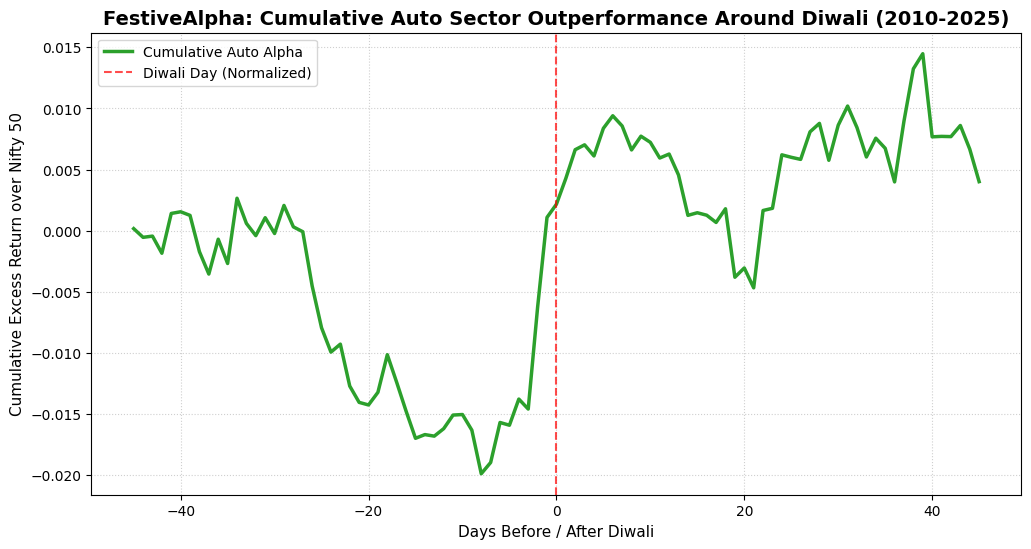

In [ ]:
# Isolate the core festive window (-45 days before to +45 days after Diwali)
festive_window = df[(df['Days_To_Diwali'] >= -45) & (df['Days_To_Diwali'] <= 45)]

# Group by the relative days to see the average cumulative outperformance behavior
pivot_window = festive_window.groupby('Days_To_Diwali')['Auto_Alpha'].mean().cumsum()

# Plotting the visual trend line
plt.figure(figsize=(12, 6))
plt.plot(pivot_window.index, pivot_window.values, color='#2ca02c', lw=2.5, label='Cumulative Auto Alpha')
plt.axvline(x=0, color='red', linestyle='--', alpha=0.7, label='Diwali Day (Normalized)')
plt.title('FestiveAlpha: Cumulative Auto Sector Outperformance Around Diwali (2010-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Days Before / After Diwali', fontsize=11)
plt.ylabel('Cumulative Excess Return over Nifty 50', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

In [ ]:
# ==========================================
# PHASE 3: FEATURE ARCHITECTURE & MODEL TRAINING
# Project: FestiveAlpha
# ==========================================

import os
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

# 1. Re-load our engineered dataset from Phase 2
# (Assuming 'df' is still active in your Colab runtime)
# If not, uncomment the line below to reload:
# df = pd.read_csv("data/raw/raw_market_indices.csv", parse_dates=['Date'], index_col='Date') # and re-run your Phase 2 return/days calculations

print("🛠️ Transforming features for Machine Learning pipeline...")

# 2. Create Lagged and Rolling Features (Preventing Data Leakage)
# We use .shift(1) because a model predicting tomorrow cannot use today's closing return
df['Auto_Ret_Lag1'] = df['NIFTY_AUTO_Ret'].shift(1)
df['Fin_Ret_Lag1'] = df['NIFTY_FIN_Ret'].shift(1)

# Rolling Momentum (past 5 and 10 trading days)
df['Auto_RollRet_5d'] = df['NIFTY_AUTO_Ret'].shift(1).rolling(window=5).mean()
df['Fin_RollRet_5d'] = df['NIFTY_FIN_Ret'].shift(1).rolling(window=5).mean()
df['Auto_RollRet_10d'] = df['NIFTY_AUTO_Ret'].shift(1).rolling(window=10).mean()
df['Fin_RollRet_10d'] = df['NIFTY_FIN_Ret'].shift(1).rolling(window=10).mean()

# Rolling Volatility (Risk proxy)
df['Auto_Vol_5d'] = df['NIFTY_AUTO_Ret'].shift(1).rolling(window=5).std()

# 3. Define the Predictive Target (Forward-Looking 5-Day Alpha)
# Look ahead 5 days, calculate cumulative auto alpha, and check if it's greater than 0
forward_auto_cum = df['NIFTY_AUTO_Ret'].rolling(window=5).sum().shift(-5)
forward_nifty_cum = df['NIFTY_50_Ret'].rolling(window=5).sum().shift(-5)
df['Target_Alpha_Outperformance'] = (forward_auto_cum > forward_nifty_cum).astype(int)

# Clean up any NaN rows created by rolling windows and look-aheads
ml_df = df.dropna()

# 4. Define Feature List (X) and Target (y)
features = [
    'Days_To_Diwali', 'Auto_Ret_Lag1', 'Fin_Ret_Lag1',
    'Auto_RollRet_5d', 'Fin_RollRet_5d', 'Auto_RollRet_10d',
    'Fin_RollRet_10d', 'Auto_Vol_5d'
]

X = ml_df[features]
y = ml_df['Target_Alpha_Outperformance']

print(f"✅ Feature matrix constructed. Total samples: {len(X)}")

🛠️ Transforming features for Machine Learning pipeline...
✅ Feature matrix constructed. Total samples: 4031


In [ ]:
# 5. Initialize Chronological Time-Series Splitter
tscv = TimeSeriesSplit(n_splits=5)

acc_scores = []
auc_scores = []

print("\n🚀 Commencing Time-Series Walk-Forward Validation...")
print("-" * 50)

# Walk through the temporal folds
for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Initialize a robust Random Forest Classifier
    model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42, class_weight='balanced')
    model.fit(X_train, y_train)

    # Predict
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]

    # Evaluate
    acc = accuracy_score(y_test, preds)
    auc = roc_auc_score(y_test, probs)

    acc_scores.append(acc)
    auc_scores.append(auc)

    print(f"Fold {fold+1} -> Training Window: {X_train.index.min().date()} to {X_train.index.max().date()} | Accuracy: {acc:.2%}")

print("-" * 50)
print(f"🏆 Mean Validation Accuracy: {np.mean(acc_scores):.2%}")
print(f"🏆 Mean ROC-AUC Score: {np.mean(auc_scores):.2%}")

# 6. View Feature Importances to see if 'Days_To_Diwali' actually matters!
importances = model.feature_importances_
feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

print("\n📊 Feature Importance Rankings:")
print(feat_imp)


🚀 Commencing Time-Series Walk-Forward Validation...
--------------------------------------------------
Fold 1 -> Training Window: 2010-01-19 to 2012-10-09 | Accuracy: 53.35%
Fold 2 -> Training Window: 2010-01-19 to 2015-07-08 | Accuracy: 49.93%
Fold 3 -> Training Window: 2010-01-19 to 2018-03-27 | Accuracy: 51.12%
Fold 4 -> Training Window: 2010-01-19 to 2020-12-18 | Accuracy: 44.11%
Fold 5 -> Training Window: 2010-01-19 to 2023-09-04 | Accuracy: 59.31%
--------------------------------------------------
🏆 Mean Validation Accuracy: 51.56%
🏆 Mean ROC-AUC Score: 51.55%

📊 Feature Importance Rankings:
Days_To_Diwali      0.270926
Auto_RollRet_5d     0.216172
Auto_Vol_5d         0.192373
Auto_Ret_Lag1       0.176533
Auto_RollRet_10d    0.143996
Fin_Ret_Lag1        0.000000
Fin_RollRet_5d      0.000000
Fin_RollRet_10d     0.000000
dtype: float64


💰 Simulating FestiveAlpha Trading Strategy...
--------------------------------------------------
📈 Performance over Test Window (2023-09-05 to 2026-05-29):
   • Baseline Nifty 50 Return        : 20.58%
   • Buy-and-Hold Nifty Auto Return  : 65.20%
   • FestiveAlpha ML Strategy Return : 62.67%
--------------------------------------------------


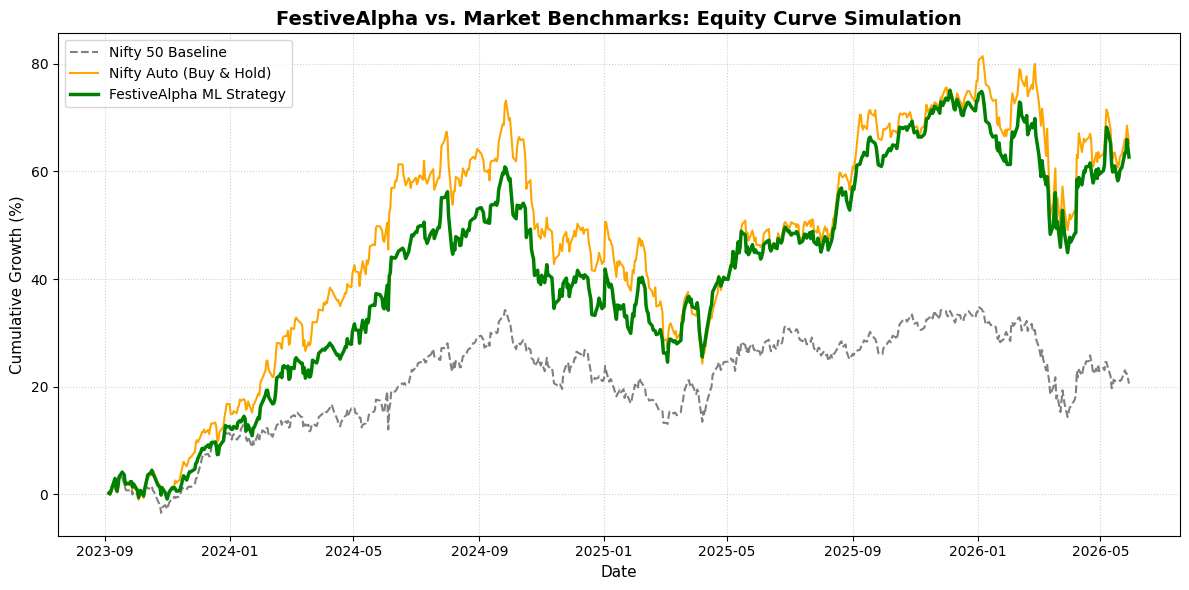

In [ ]:
# ==========================================
# PHASE 4: QUANTITATIVE BACKTESTING ENGINE
# Project: FestiveAlpha
# ==========================================

print("💰 Simulating FestiveAlpha Trading Strategy...")

# 1. Use the trained model from Phase 3 to generate predictions on our test set
# (We will use the last fold's X_test and y_test for this simulation)
test_df = ml_df.loc[X_test.index].copy()
test_df['Model_Signal'] = model.predict(X_test)

# 2. Calculate Strategy Returns
# If the model predicts 1 (Outperformance), we go Long (buy) Nifty Auto.
# If the model predicts 0, we sit in cash (0% return) or stay in the Nifty 50 baseline.
# Let's say if signal is 0, we just hold the benchmark Nifty 50 to see if we beat it.
test_df['Strategy_Return'] = np.where(test_df['Model_Signal'] == 1,
                                      test_df['NIFTY_AUTO_Ret'],
                                      test_df['NIFTY_50_Ret'])

# 3. Compute Cumulative Compounded Returns
test_df['Cum_Nifty50'] = (1 + test_df['NIFTY_50_Ret']).cumprod() - 1
test_df['Cum_NiftyAuto'] = (1 + test_df['NIFTY_AUTO_Ret']).cumprod() - 1
test_df['Cum_FestiveAlpha'] = (1 + test_df['Strategy_Return']).cumprod() - 1

# 4. Print Performance Metrics
final_nifty = test_df['Cum_Nifty50'].iloc[-1]
final_auto = test_df['Cum_NiftyAuto'].iloc[-1]
final_strategy = test_df['Cum_FestiveAlpha'].iloc[-1]

print("-" * 50)
print(f"📈 Performance over Test Window ({X_test.index.min().date()} to {X_test.index.max().date()}):")
print(f"   • Baseline Nifty 50 Return        : {final_nifty:.2%}")
print(f"   • Buy-and-Hold Nifty Auto Return  : {final_auto:.2%}")
print(f"   • FestiveAlpha ML Strategy Return : {final_strategy:.2%}")
print("-" * 50)

# 5. Plot the Equity Curves
plt.figure(figsize=(12, 6))
plt.plot(test_df.index, test_df['Cum_Nifty50'] * 100, label='Nifty 50 Baseline', color='gray', linestyle='--')
plt.plot(test_df.index, test_df['Cum_NiftyAuto'] * 100, label='Nifty Auto (Buy & Hold)', color='orange')
plt.plot(test_df.index, test_df['Cum_FestiveAlpha'] * 100, label='FestiveAlpha ML Strategy', color='green', lw=2.5)

plt.title('FestiveAlpha vs. Market Benchmarks: Equity Curve Simulation', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=11)
plt.ylabel('Cumulative Growth (%)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()